<a href="https://colab.research.google.com/github/duncanian303-cloud/Tsunami-earthquakes-detection/blob/main/notebooks/Earthquake_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the data from the CSV file
df = pd.read_csv('/content/earthquake_data_tsunami.csv')

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [ ]:
import pandas as pd

# Check for missing values in the updated DataFrame
missing_values_updated = df.isnull().sum()
print("Missing values per column:")
display(missing_values_updated)

Missing values per column:


,0
magnitude,0
cdi,0
mmi,0
sig,0
nst,0
dmin,0
gap,0
depth,0
latitude,0
longitude,0


In [ ]:
import pandas as pd

# Group by 'tsunami' and calculate average values
tsunami_grouped_avg = df.groupby('tsunami').mean()
display(tsunami_grouped_avg)

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude
tsunami,,,,,,,,,,
0,6.942803,3.928870,6.135983,874.092050,349.933054,0.617095,22.792448,69.667356,6.001553,65.461177
1,6.938487,4.970395,5.694079,863.845395,42.065789,2.440036,28.571382,85.656796,-0.335356,32.401155


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [ ]:
# Display summary statistics for the DataFrame
display(df.describe())

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [ ]:
df.drop(columns=['Year', 'Month'], inplace=True)
display(df.head())

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,1


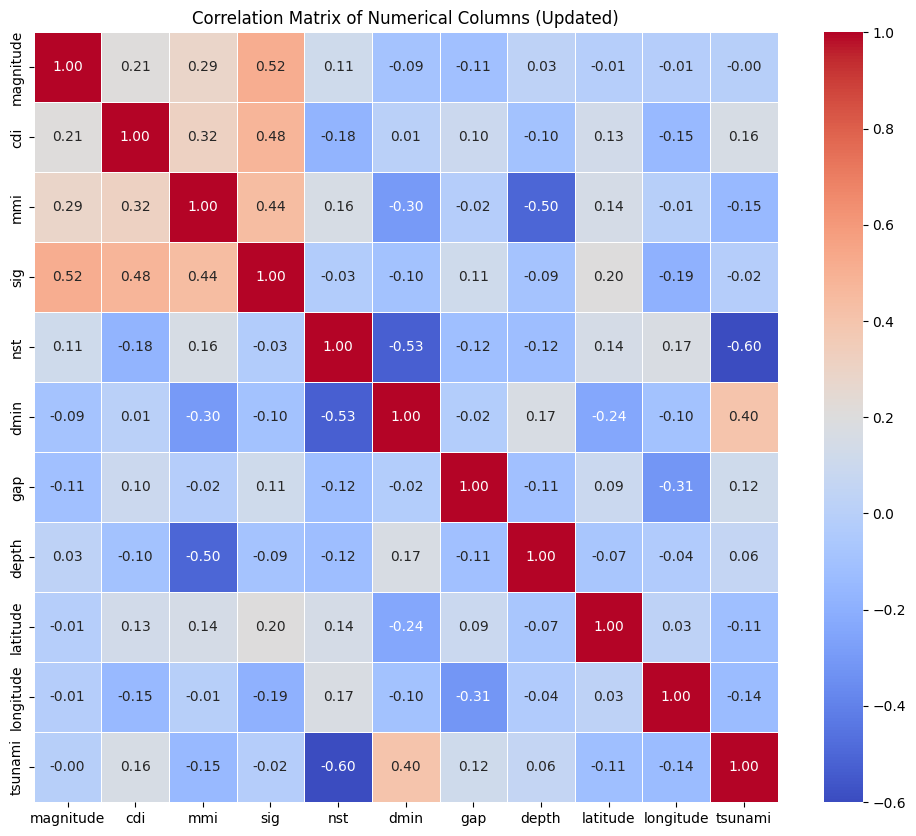

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recalculate correlation on the updated df (without Year and Month)
updated_correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(updated_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns (Updated)')
plt.show()

### Machine Learning: Predicting Tsunami Occurrence
We will use the earthquake features (magnitude, depth, sig, etc.) to predict the `tsunami` binary target.

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        96
           1       0.87      0.89      0.88        61

    accuracy                           0.90       157
   macro avg       0.90      0.90      0.90       157
weighted avg       0.90      0.90      0.90       157



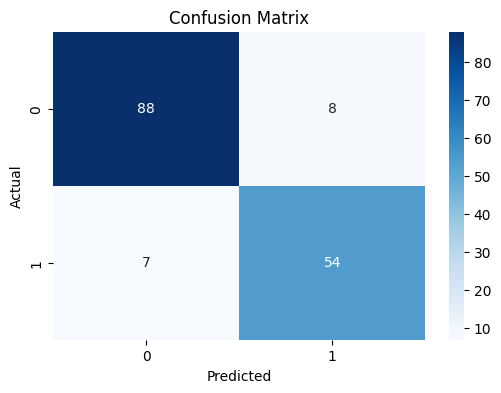

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Define features and target
X = df.drop('tsunami', axis=1)
y = df['tsunami']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

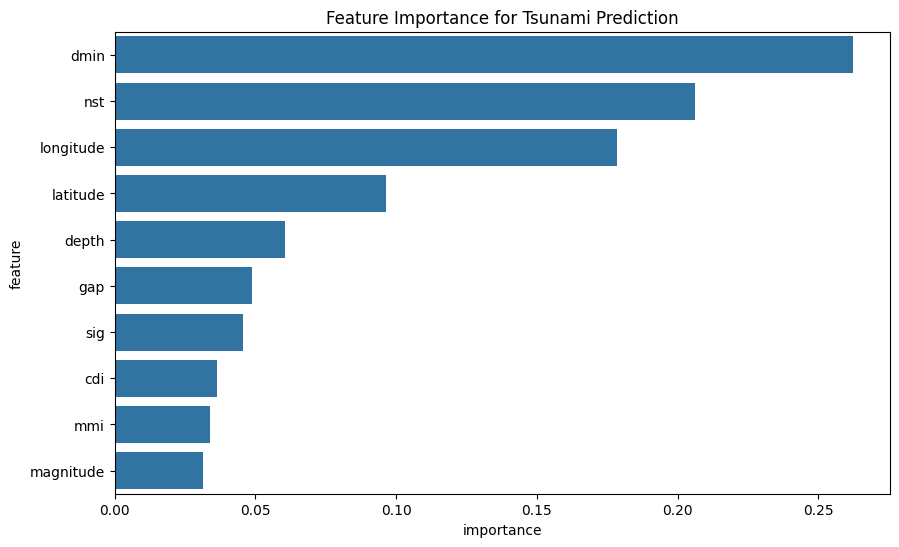

In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance for Tsunami Prediction')
plt.show()

### XGBoost Classifier
We will now try XGBoost to see if gradient boosting provides better predictive power for tsunami events.

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost Classifier
# We use scale_pos_weight to handle the class imbalance (ratio of majority to minority class)
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

xgb_model = XGBClassifier(n_estimators=100,
                           learning_rate=0.1,
                           max_depth=6,
                           scale_pos_weight=ratio,
                           random_state=42,
                           use_label_encoder=False,
                           eval_metric='logloss')

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate XGBoost
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Comparison with Random Forest (Best model from previous step)
print(f"Random Forest F1-Score (Tsunami): {classification_report(y_test, y_pred_improved, output_dict=True)['1']['f1-score']:.2f}")
print(f"XGBoost F1-Score (Tsunami): {classification_report(y_test, y_pred_xgb, output_dict=True)['1']['f1-score']:.2f}")

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        96
           1       0.87      0.89      0.88        61

    accuracy                           0.90       157
   macro avg       0.90      0.90      0.90       157
weighted avg       0.90      0.90      0.90       157

Random Forest F1-Score (Tsunami): 0.86
XGBoost F1-Score (Tsunami): 0.88


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:56:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Cross-Validation for XGBoost Stability
We will use 5-fold cross-validation to assess how the model generalizes across different segments of the data.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Cross-Validation F1-scores: [0.53588517 0.84615385 0.98360656 0.91056911 0.68085106]
Mean F1-score: 0.7914
Standard Deviation of F1-score: 0.1623


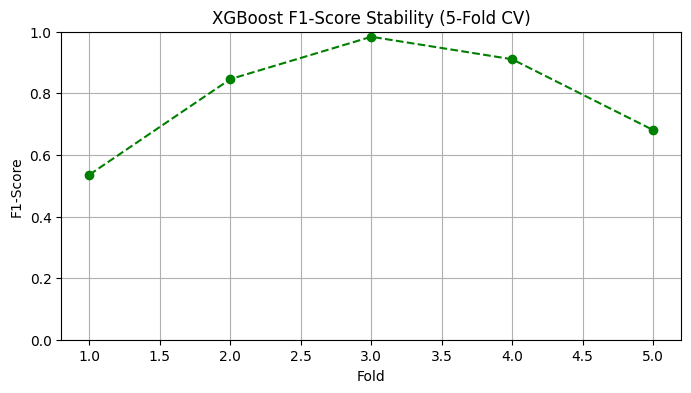

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5-fold cross-validation
# Using F1-score as the scoring metric since it was our primary point of comparison
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1')

print(f"Cross-Validation F1-scores: {cv_scores}")
print(f"Mean F1-score: {cv_scores.mean():.4f}")
print(f"Standard Deviation of F1-score: {cv_scores.std():.4f}")

# Visualize the stability
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='--', color='green')
plt.title('XGBoost F1-Score Stability (5-Fold CV)')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

### Hyperparameter Tuning for XGBoost
We'll use `GridSearchCV` to optimize the XGBoost classifier's hyperparameters, focusing on improving the F1-score.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit the grid search
grid_search_xgb.fit(X_train, y_train)

# Get the best parameters and model
best_xgb_model = grid_search_xgb.best_estimator_
print(f"Best Parameters: {grid_search_xgb.best_params_}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


Optimized XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        96
           1       0.86      0.89      0.87        61

    accuracy                           0.90       157
   macro avg       0.89      0.90      0.89       157
weighted avg       0.90      0.90      0.90       157



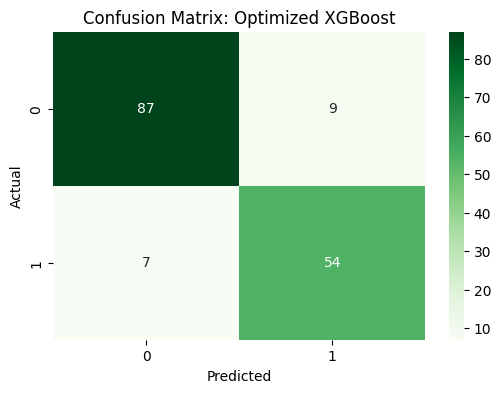

In [ ]:
# Evaluate the optimized model
y_pred_best_xgb = best_xgb_model.predict(X_test)

print("Optimized XGBoost Classification Report:")
print(classification_report(y_test, y_pred_best_xgb))

# Confusion Matrix for optimized model
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best_xgb), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Optimized XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Cross-Validation for Optimized XGBoost
We'll perform a 5-fold cross-validation on the optimized model to check for performance stability.

Optimized Cross-Validation F1-scores: [0.54028436 0.94214876 0.976      0.95238095 0.70707071]
Mean F1-score: 0.8236
Standard Deviation: 0.1719


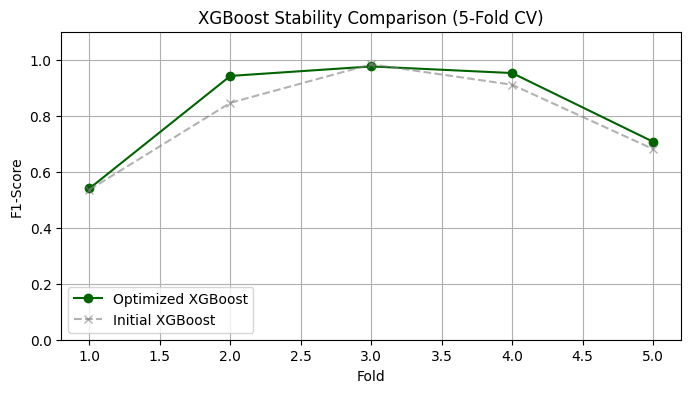

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Perform 5-fold cross-validation on the best model
# Note: best_xgb_model already contains the scale_pos_weight and other tuned parameters
cv_scores_optimized = cross_val_score(best_xgb_model, X, y, cv=5, scoring='f1')

print(f"Optimized Cross-Validation F1-scores: {cv_scores_optimized}")
print(f"Mean F1-score: {cv_scores_optimized.mean():.4f}")
print(f"Standard Deviation: {cv_scores_optimized.std():.4f}")

# Visualize stability
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores_optimized, marker='o', label='Optimized XGBoost', color='darkgreen')
plt.plot(range(1, 6), cv_scores, marker='x', linestyle='--', label='Initial XGBoost', color='gray', alpha=0.6)
plt.title('XGBoost Stability Comparison (5-Fold CV)')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)
plt.show()

### Error Analysis: Misclassified Cases
Analyzing the specific instances where the model failed can provide insights into potential feature engineering needs or data quality issues.

In [ ]:
import pandas as pd

# Create a DataFrame for the test set results
analysis_df = X_test.copy()
analysis_df['actual'] = y_test
analysis_df['predicted'] = y_pred_best_xgb

# Identify misclassified instances
misclassified = analysis_df[analysis_df['actual'] != analysis_df['predicted']]

print(f"Total misclassified cases: {len(misclassified)}")
print("\nSummary of Misclassified Cases:")
display(misclassified.describe())

print("\nFirst 10 Misclassified Instances:")
display(misclassified.head(10))

Total misclassified cases: 16

Summary of Misclassified Cases:


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,actual,predicted
count,16.00000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,6.90625,3.875000,5.875000,876.000000,124.375000,1.031250,18.318750,113.487375,14.065700,-33.902306,0.437500,0.562500
std,0.46543,3.030402,1.087811,297.213952,218.388912,1.611895,14.550107,151.004093,34.899993,149.326499,0.512348,0.512348
min,6.50000,0.000000,4.000000,651.000000,0.000000,0.000000,0.000000,10.000000,-31.562200,-177.607000,0.000000,0.000000
25%,6.60000,0.000000,5.000000,685.750000,0.000000,0.000000,11.125000,27.955000,-13.767725,-159.833250,0.000000,0.000000
50%,6.75000,4.500000,6.000000,756.000000,0.000000,0.312000,16.300000,42.200000,6.071050,-110.607850,0.000000,1.000000
75%,7.02500,5.250000,6.250000,869.500000,146.500000,1.241750,22.250000,167.175000,50.113350,135.182000,1.000000,1.000000
max,8.30000,9.000000,8.000000,1686.000000,626.000000,5.931000,53.000000,598.100000,58.775000,165.741000,1.000000,1.000000



First 10 Misclassified Instances:


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,actual,predicted
98,6.6,5,4,734,0,2.015,18.0,165.00,28.9386,128.262,1,0
69,6.5,4,4,651,0,5.931,20.0,246.00,-21.6857,-177.064,0,1
407,6.6,0,6,670,421,0.000,16.6,18.00,-10.9940,165.741,1,0
401,6.6,0,5,670,491,0.000,11.5,31.00,-6.4750,154.607,1,0
126,7.3,4,6,952,0,2.629,16.0,212.00,-6.4078,129.169,1,0
762,6.6,6,6,754,0,0.000,0.0,131.80,58.7750,-154.701,0,1
778,6.9,5,7,745,0,0.000,0.0,36.40,56.7744,-153.281,0,1
382,7.0,5,6,758,0,0.624,53.0,29.00,51.5370,-175.230,0,1
337,6.7,0,5,691,0,0.748,43.0,26.59,-29.9414,-177.607,0,1
347,6.6,0,6,670,0,2.666,22.0,10.00,-11.1284,162.052,0,1


/tmp/ipykernel_9991/1170326904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_correct', y=col, data=analysis_df, ax=axes[i], palette='Set2')
/tmp/ipykernel_9991/1170326904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_correct', y=col, data=analysis_df, ax=axes[i], palette='Set2')
/tmp/ipykernel_9991/1170326904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_correct', y=col, data=analysis_df, ax=axes[i], palette='Set2')
/tmp/ipykernel_9991/1170326904.py:9: FutureWarning: 

Passing `palette` without assigning `

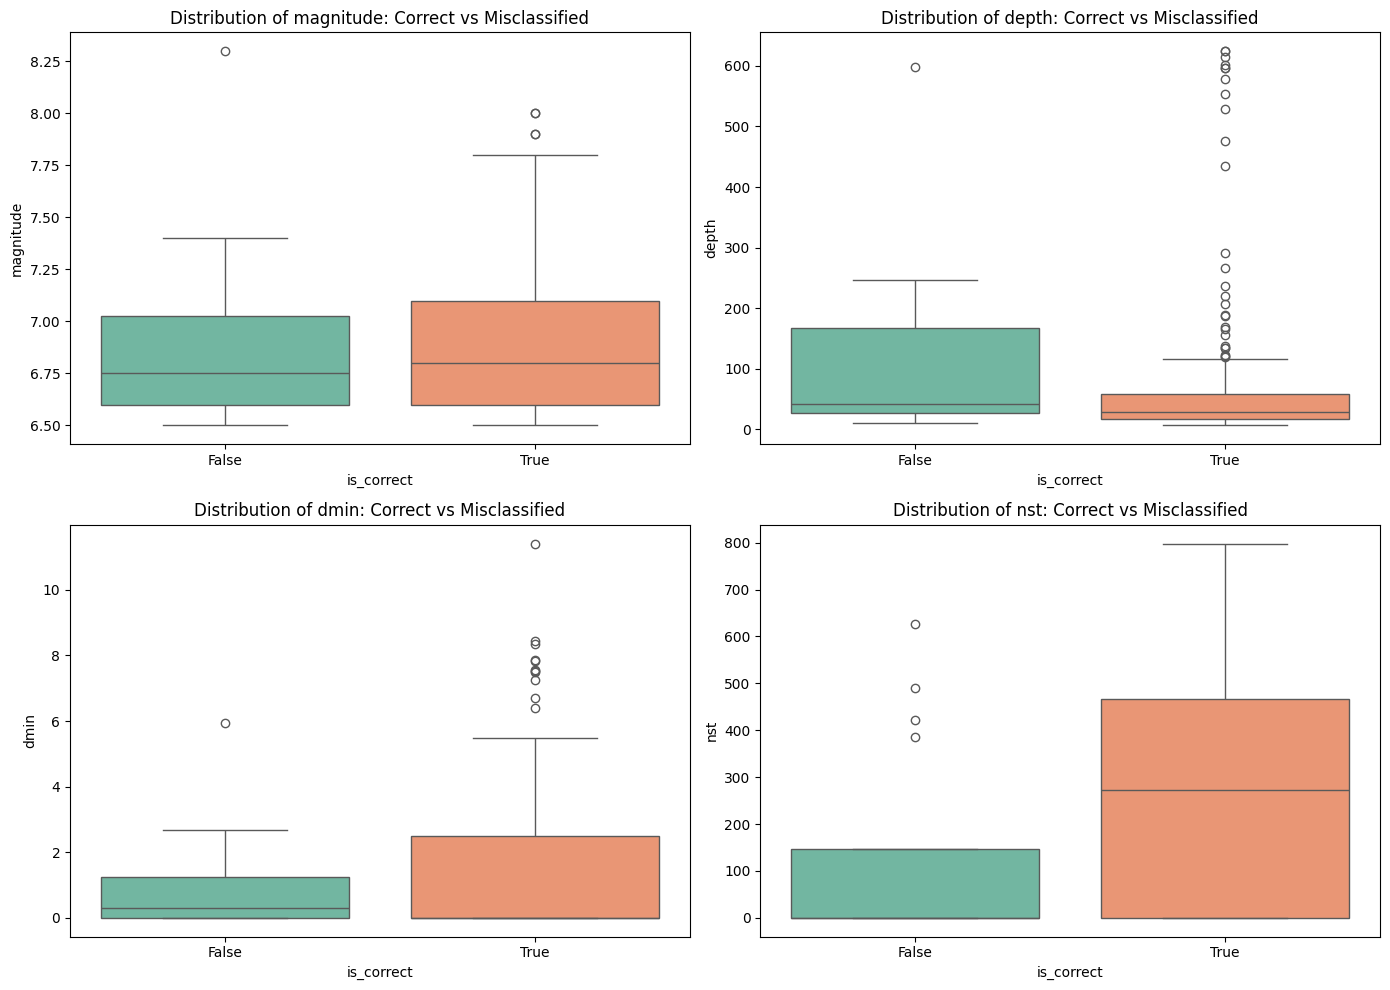

In [ ]:
# Compare feature distributions: Correct vs Misclassified
analysis_df['is_correct'] = analysis_df['actual'] == analysis_df['predicted']

features_to_plot = ['magnitude', 'depth', 'dmin', 'nst']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='is_correct', y=col, data=analysis_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col}: Correct vs Misclassified')

plt.tight_layout()
plt.show()

### Feature Engineering: Depth Categorization
We will create a categorical feature `is_deep` based on a 70km threshold, which is a common boundary in seismology to distinguish shallow-focus from deep-focus earthquakes.

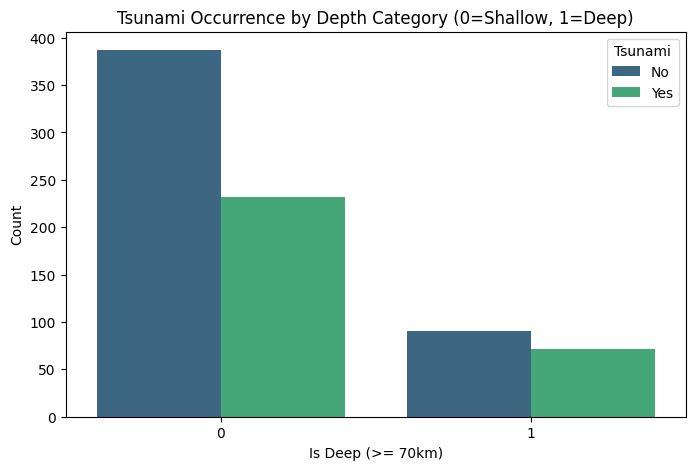

Depth Category Counts:


,count
is_deep,
0,619
1,163



New feature 'is_deep' added and training sets updated.


In [ ]:
# Create the new feature
df['is_deep'] = (df['depth'] >= 70).astype(int)

# Visualize the relationship between the new feature and tsunami occurrence
plt.figure(figsize=(8, 5))
sns.countplot(x='is_deep', hue='tsunami', data=df, palette='viridis')
plt.title('Tsunami Occurrence by Depth Category (0=Shallow, 1=Deep)')
plt.xlabel('Is Deep (>= 70km)')
plt.ylabel('Count')
plt.legend(title='Tsunami', labels=['No', 'Yes'])
plt.show()

# Display the count distribution
print("Depth Category Counts:")
display(df['is_deep'].value_counts())

# Re-split the data with the new feature included
X_new = df.drop('tsunami', axis=1)
y_new = df['tsunami']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

print("\nNew feature 'is_deep' added and training sets updated.")

### Retraining Optimized XGBoost with Engineered Feature
We will now use the best hyperparameters found earlier (`learning_rate=0.1`, `max_depth=3`, `n_estimators=50`, `subsample=0.8`) to retrain the model on the updated feature set.

XGBoost with 'is_deep' Feature - Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        96
           1       0.86      0.89      0.87        61

    accuracy                           0.90       157
   macro avg       0.89      0.90      0.89       157
weighted avg       0.90      0.90      0.90       157



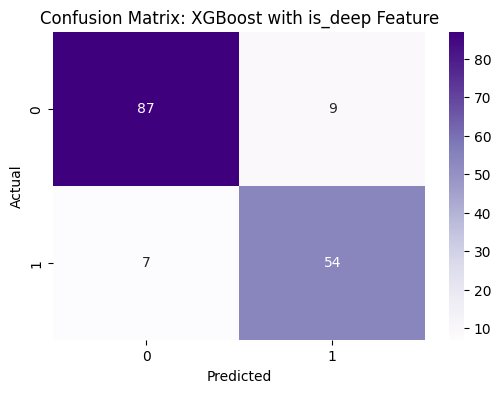

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the model with previously found best parameters
# Note: scale_pos_weight is kept to handle class imbalance
retrained_xgb = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

# Train on the new training set
retrained_xgb.fit(X_train_new, y_train_new)

# Predict on the new test set
y_pred_retrained = retrained_xgb.predict(X_test_new)

# Evaluation
print("XGBoost with 'is_deep' Feature - Classification Report:")
print(classification_report(y_test_new, y_pred_retrained))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_new, y_pred_retrained), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: XGBoost with is_deep Feature')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()